# TorNet End-to-End Demo

Live walkthrough for the Wednesday presentation:

1. **MADIS data acquisition** — how MADIS surface-weather URLs are generated and how the final feature table is saved (no live network calls in this notebook).
2. **Four fast training runs** — No MADIS, MADIS (hybrid/late-fusion), MADIS top-3, MADIS FiLM, each trained for 1 epoch on a small local subset just to show the pipeline running end-to-end.
3. **Bridge to full results** — pointer to `july_21st_result_analysis.ipynb` for the real, fully-trained comparison graphs (presented separately, live).
4. **Prediction API** — call the Flask API directly with `requests`, then switch to the Rails frontend to show the same prediction consumed live.

**Before running:** start the Flask API in a separate terminal for section 4 (`export TORNET_ROOT=...`, `export KERAS_BACKEND=tensorflow`, `python api/app.py`). Everything else in this notebook runs fully offline against local data.

In [1]:
import copy
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Repo root is one level up from notebooks/
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
for path in (REPO_ROOT, os.path.join(REPO_ROOT, "scripts", "tornado_detection")):
    if path not in sys.path:
        sys.path.insert(0, path)

# TORNET_ROOT/KERAS_BACKEND/EXP_DIR must be set before importing train_tornado_keras,
# since that module reads them at import time.
os.environ.setdefault("TORNET_ROOT", os.path.join(REPO_ROOT, "tornet_data"))
os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("EXP_DIR", os.path.join(REPO_ROOT, "results", "presentation_demo_runs"))

TORNET_ROOT = os.environ["TORNET_ROOT"]
print(f"TORNET_ROOT = {TORNET_ROOT}")
print(f"KERAS_BACKEND = {os.environ['KERAS_BACKEND']}")
print(f"EXP_DIR = {os.environ['EXP_DIR']}")

TORNET_ROOT = /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data
KERAS_BACKEND = tensorflow
EXP_DIR = /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/results/presentation_demo_runs


## 1. MADIS data acquisition

### 1a. Generating MADIS request URLs

`generate_madis_urls.py` builds the MADIS APRSWXNET bounding-box URL for a storm — this is a pure string-building function, no network I/O. We'll run it over a handful of real storms to show the URL generation live.

In [2]:
from generate_madis_urls import (
    get_bounding_box,
    convert_to_timestamp,
    get_id_from_storm_event_url,
    set_madis_url,
    generate_url_list,
)

data_root = Path(TORNET_ROOT)
catalog = pd.read_csv(data_root / "catalog.csv", parse_dates=["start_time", "end_time"])

# A tiny sample so this runs instantly during the live demo
sample = catalog[catalog.start_time.dt.year == 2013].sample(3, random_state=42)

url_df = generate_url_list(sample, data_root, years=[2013], time_windows=["T0"])
url_df[["storm_id", "adjusted_time", "url"]]

Generating URLs from 3 catalog entries...
Time windows: At-storm (during radar scan)


Processing storms: 100%|██████████| 3/3 [00:01<00:00,  2.35it/s]


Successfully generated 3 URLs
  - 3 storms
  - 1 time windows per storm



,storm_id,adjusted_time,url
0,468988,2013-09-11 21:30:00,https://madis-data.ncep.noaa.gov/madisPublic1/...
1,471956,2013-09-12 00:05:00,https://madis-data.ncep.noaa.gov/madisPublic1/...
2,472673,2013-10-04 02:03:00,https://madis-data.ncep.noaa.gov/madisPublic1/...


### 1b. Fetching (demo-safe, no network call)

`download_madis_data.py`'s `download_madis_for_storm` is the function that actually performs the `requests.get` and saves the XML response. For the live demo we wrap it in `demo_fetch_madis`, which builds and prints the exact request it *would* make, and only touches the network if you explicitly pass `dry_run=False`.

In [3]:
from download_madis_data import download_madis_for_storm, prepare_storm_list

def demo_fetch_madis(storm_info, output_dir, distance_km=20, dry_run=True, verbose=True):
    storm_id, start_time, site_lat, site_lon, filename = storm_info
    latll, lonll, latur, lonur = get_bounding_box(site_lat, site_lon, distance_km)
    timestamp = convert_to_timestamp(start_time)
    url = set_madis_url(latll, lonll, latur, lonur, timestamp)
    output_file = output_dir / f"madis_data_{storm_id}_{start_time}.xml"

    if dry_run:
        print(f"[DRY RUN] would GET:\n  {url}")
        print(f"[DRY RUN] would save to:\n  {output_file}")
        return storm_id, None, url, output_file

    return download_madis_for_storm(storm_info, output_dir, distance_km=distance_km, verbose=verbose)

storm_list = prepare_storm_list(sample, data_root, years=[2013])
demo_fetch_madis(storm_list[0], output_dir=data_root / "madis_data", dry_run=True)

Preparing storm list from 3 catalog entries...


Reading NetCDF metadata: 100%|██████████| 3/3 [00:00<00:00, 126.64it/s]


Successfully prepared 3 storms

[DRY RUN] would GET:
  https://madis-data.ncep.noaa.gov/madisPublic1/cgi-bin/madisXmlPublicDir?rdr=&time=20130911_2130&minbck=-59&minfwd=0&recwin=3&dfltrsel=1&state=&latll=42.10963190990991&lonll=-76.1063326031059&latur=42.289812090090095&lonur=-75.86311139689411&stanam=&stasel=0&pvdrsel=1&varsel=2&qctype=0&qcsel=1&xml=1&csvmiss=0&pvd=APRSWXNET
[DRY RUN] would save to:
  /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data/madis_data/madis_data_468988_2013-09-11 21:30:00.xml


('468988',
 None,
 'https://madis-data.ncep.noaa.gov/madisPublic1/cgi-bin/madisXmlPublicDir?rdr=&time=20130911_2130&minbck=-59&minfwd=0&recwin=3&dfltrsel=1&state=&latll=42.10963190990991&lonll=-76.1063326031059&latur=42.289812090090095&lonur=-75.86311139689411&stanam=&stasel=0&pvdrsel=1&varsel=2&qctype=0&qcsel=1&xml=1&csvmiss=0&pvd=APRSWXNET',
 PosixPath('/Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data/madis_data/madis_data_468988_2013-09-11 21:30:00.xml'))

### 1c. The saved, engineered feature table

Downloaded MADIS XML is parsed and reduced to 6 engineered features per storm (`scripts/build_madis_features.py`), cached at `$TORNET_ROOT/madis_features_clean.csv`. This is what the model actually consumes — no need to re-run the download/parse pipeline live, we just read the already-saved result.

In [4]:
madis_features = pd.read_csv(data_root / "madis_features_clean.csv")
madis_features.head()

,storm_id,timestamp,pressure,wind_gust,pressure_anomaly_24h,wind_anomaly_24h,instability_proxy_T2h,instability_proxy_T0,ef_number,category,type,has_madis_data
0,1000151,2022-02-24 15:09:00,102195.0,0.745067,-975.832031,-0.918916,1.255553,1.219437,-1.0,NUL,train,True
1,1000151,2022-02-24 15:16:00,102160.0,0.745067,-975.832031,-0.918916,1.255553,1.219437,-1.0,NUL,train,True
2,1000151,2022-02-24 15:37:00,102085.0,1.341120,-975.832031,-0.918916,1.255553,1.219437,-1.0,NUL,train,True
3,1000151,2022-02-24 15:44:00,102150.0,1.043093,-975.832031,-0.918916,1.255553,1.219437,-1.0,NUL,train,True
4,1000151,2022-02-24 15:51:00,102240.0,0.745067,-975.832031,-0.918916,1.255553,1.219437,-1.0,NUL,train,True


## 2. Four fast training runs

Same model code, four different MADIS configurations:

| Variant | `use_madis_data` | `head` | `madis_feature_set` | `madis_fusion` |
|---|---|---|---|---|
| No MADIS | `false` | `mlp` | — | — |
| MADIS (hybrid) | `true` | `mlp` | `full` | `late` (default) |
| MADIS top-3 | `true` | `mlp` | `top3` | `late` (default) |
| MADIS FiLM | `true` | `maxpool` | `full` | `film` |

Each config below trains for 1 epoch on ~50 local files from a single year — enough to show the pipeline running for real, not a benchmark of model quality. Full multi-run results are in the next section.

In [5]:
import train_tornado_keras as ttk

CONFIG_DIR = os.path.join(REPO_ROOT, "scripts", "tornado_detection", "config")

VARIANTS = [
    ("No MADIS", "params_no_madis_quick_test.json"),
    ("MADIS (hybrid)", "params_madis_hybrid_quick_test.json"),
    ("MADIS top-3", "params_madis_top3_quick_test.json"),
    ("MADIS FiLM", "params_madis_film_quick_test.json"),
]

def run_variant(config_path):
    with open(config_path) as f:
        overrides = json.load(f)
    # deepcopy: DEFAULT_CONFIG's dataloader_kwargs dict is shared across calls,
    # a shallow copy would leak mutations (e.g. use_madis_data) between variants.
    config = copy.deepcopy(ttk.DEFAULT_CONFIG)
    config.update(overrides)
    return ttk.main(config)

INFO:root:TORNET_ROOT=/Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data


In [6]:
results = []
for label, fname in VARIANTS:
    print(f"\n=== Training: {label} ===")
    metrics = run_variant(os.path.join(CONFIG_DIR, fname))
    results.append({"variant": label, **metrics})

results_df = pd.DataFrame(results)
results_df

INFO:root:Using tensorflow backend
INFO:root:Using keras dataloader
INFO:root:Running with config:
INFO:root:{'epochs': 1, 'input_variables': ['DBZ', 'VEL', 'KDP', 'RHOHV', 'ZDR', 'WIDTH'], 'train_years': [2013], 'val_years': [2021], 'batch_size': 16, 'model': 'vgg', 'start_filters': 48, 'learning_rate': 0.0001, 'decay_steps': 1386, 'decay_rate': 0.958, 'l2_reg': 1e-05, 'wN': 1.0, 'w0': 1.0, 'w1': 1.0, 'w2': 2.0, 'wW': 0.5, 'label_smooth': 0, 'loss': 'cce', 'head': 'mlp', 'exp_name': 'tornado_no_madis_quick_test', 'exp_dir': '/Users/evanshabsove/Documents/tornado_reserch_paper/tornet/results/presentation_demo_runs', 'dataloader': 'keras', 'dataloader_kwargs': {}, 'use_madis_data': False, 'catalog_path': '/Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data/catalog_madis_eligible.csv', 'max_files': 50, 'early_stopping_patience': 3}
INFO:root:Using pre-filtered catalog: /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data/catalog_madis_eligible.csv (10


=== Training: No MADIS ===


INFO:root:Using ExponentialDecay: decay_steps=1386, decay_rate=0.958
INFO:root:expdir=/Users/evanshabsove/Documents/tornado_reserch_paper/tornet/results/presentation_demo_runs/tornado_no_madis_quick_test260803140406-None-None
INFO:root:Epoch 1/1
INFO:root:Epoch 1/1 — AUC: 0.2527  AUCPR: 0.0509  BinaryAccuracy: 0.6200  F1: 0.0000  FalseNegatives: 4.0000  FalsePositives: 15.0000  Precision: 0.0000  Recall: 0.0000  TrueNegatives: 31.0000  TruePositives: 0.0000  loss: 1.2258  val_AUC: 0.2240  val_AUCPR: 0.0249  val_BinaryAccuracy: 0.9600  val_F1: 0.0000  val_FalseNegatives: 2.0000  val_FalsePositives: 0.0000  val_Precision: 0.0000  val_Recall: 0.0000  val_TrueNegatives: 48.0000  val_TruePositives: 0.0000  val_loss: 0.3243
INFO:root:New best val_AUC=0.2240 — saved checkpoint: /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/results/presentation_demo_runs/tornado_no_madis_quick_test260803140406-None-None/checkpoints/tornadoDetector_best.keras
INFO:root:Using tensorflow backend
INFO


=== Training: MADIS (hybrid) ===


INFO:root:Using pre-filtered catalog: /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data/catalog_madis_eligible.csv (105108 rows)
INFO:root:Using ExponentialDecay: decay_steps=1386, decay_rate=0.958
INFO:root:expdir=/Users/evanshabsove/Documents/tornado_reserch_paper/tornet/results/presentation_demo_runs/tornado_madis_hybrid_quick_test260803140420-None-None
INFO:root:Epoch 1/1
INFO:root:Epoch 1/1 — AUC: 0.4185  AUCPR: 0.0648  BinaryAccuracy: 0.6600  F1: 0.0000  FalseNegatives: 4.0000  FalsePositives: 13.0000  Precision: 0.0000  Recall: 0.0000  TrueNegatives: 33.0000  TruePositives: 0.0000  loss: 0.9809  val_AUC: 0.2917  val_AUCPR: 0.0271  val_BinaryAccuracy: 0.9600  val_F1: 0.0000  val_FalseNegatives: 2.0000  val_FalsePositives: 0.0000  val_Precision: 0.0000  val_Recall: 0.0000  val_TrueNegatives: 48.0000  val_TruePositives: 0.0000  val_loss: 0.3016
INFO:root:New best val_AUC=0.2917 — saved checkpoint: /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/resul


=== Training: MADIS top-3 ===


INFO:root:Using ExponentialDecay: decay_steps=1386, decay_rate=0.958
INFO:root:expdir=/Users/evanshabsove/Documents/tornado_reserch_paper/tornet/results/presentation_demo_runs/tornado_madis_top3_quick_test260803140433-None-None
INFO:root:Epoch 1/1
INFO:root:Epoch 1/1 — AUC: 0.3370  AUCPR: 0.0559  BinaryAccuracy: 0.8400  F1: 0.0000  FalseNegatives: 4.0000  FalsePositives: 4.0000  Precision: 0.0000  Recall: 0.0000  TrueNegatives: 42.0000  TruePositives: 0.0000  loss: 1.2158  val_AUC: 0.2396  val_AUCPR: 0.0255  val_BinaryAccuracy: 0.9600  val_F1: 0.0000  val_FalseNegatives: 2.0000  val_FalsePositives: 0.0000  val_Precision: 0.0000  val_Recall: 0.0000  val_TrueNegatives: 48.0000  val_TruePositives: 0.0000  val_loss: 0.3091
INFO:root:New best val_AUC=0.2396 — saved checkpoint: /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/results/presentation_demo_runs/tornado_madis_top3_quick_test260803140433-None-None/checkpoints/tornadoDetector_best.keras
INFO:root:Using tensorflow backend
I


=== Training: MADIS FiLM ===


INFO:root:Using ExponentialDecay: decay_steps=1386, decay_rate=0.958
INFO:root:expdir=/Users/evanshabsove/Documents/tornado_reserch_paper/tornet/results/presentation_demo_runs/tornado_madis_film_quick_test260803140445-None-None
INFO:root:Epoch 1/1
INFO:root:Epoch 1/1 — AUC: 0.3370  AUCPR: 0.0558  BinaryAccuracy: 0.9200  F1: 0.0000  FalseNegatives: 4.0000  FalsePositives: 0.0000  Precision: 0.0000  Recall: 0.0000  TrueNegatives: 46.0000  TruePositives: 0.0000  loss: 0.5793  val_AUC: 0.3229  val_AUCPR: 0.0287  val_BinaryAccuracy: 0.9600  val_F1: 0.0000  val_FalseNegatives: 2.0000  val_FalsePositives: 0.0000  val_Precision: 0.0000  val_Recall: 0.0000  val_TrueNegatives: 48.0000  val_TruePositives: 0.0000  val_loss: 0.3350
INFO:root:New best val_AUC=0.3229 — saved checkpoint: /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/results/presentation_demo_runs/tornado_madis_film_quick_test260803140445-None-None/checkpoints/tornadoDetector_best.keras


,variant,AUC,AUCPR
0,No MADIS,0.223958,0.024907
1,MADIS (hybrid),0.291667,0.027114
2,MADIS top-3,0.239583,0.025476
3,MADIS FiLM,0.322917,0.028671


*Note: these are 1-epoch/~50-file toy runs meant to show the training pipeline live — not representative of real model performance.*

## 3. Full results (separate notebook)

The toy runs above only demonstrate that the pipeline works end-to-end. The real performance comparison — across full multi-run sweeps, with significance testing, AUC/precision-recall curves, and overfitting analysis — lives in **`notebooks/july_21st_result_analysis.ipynb`**, presented separately live.

A preview of one of those results:

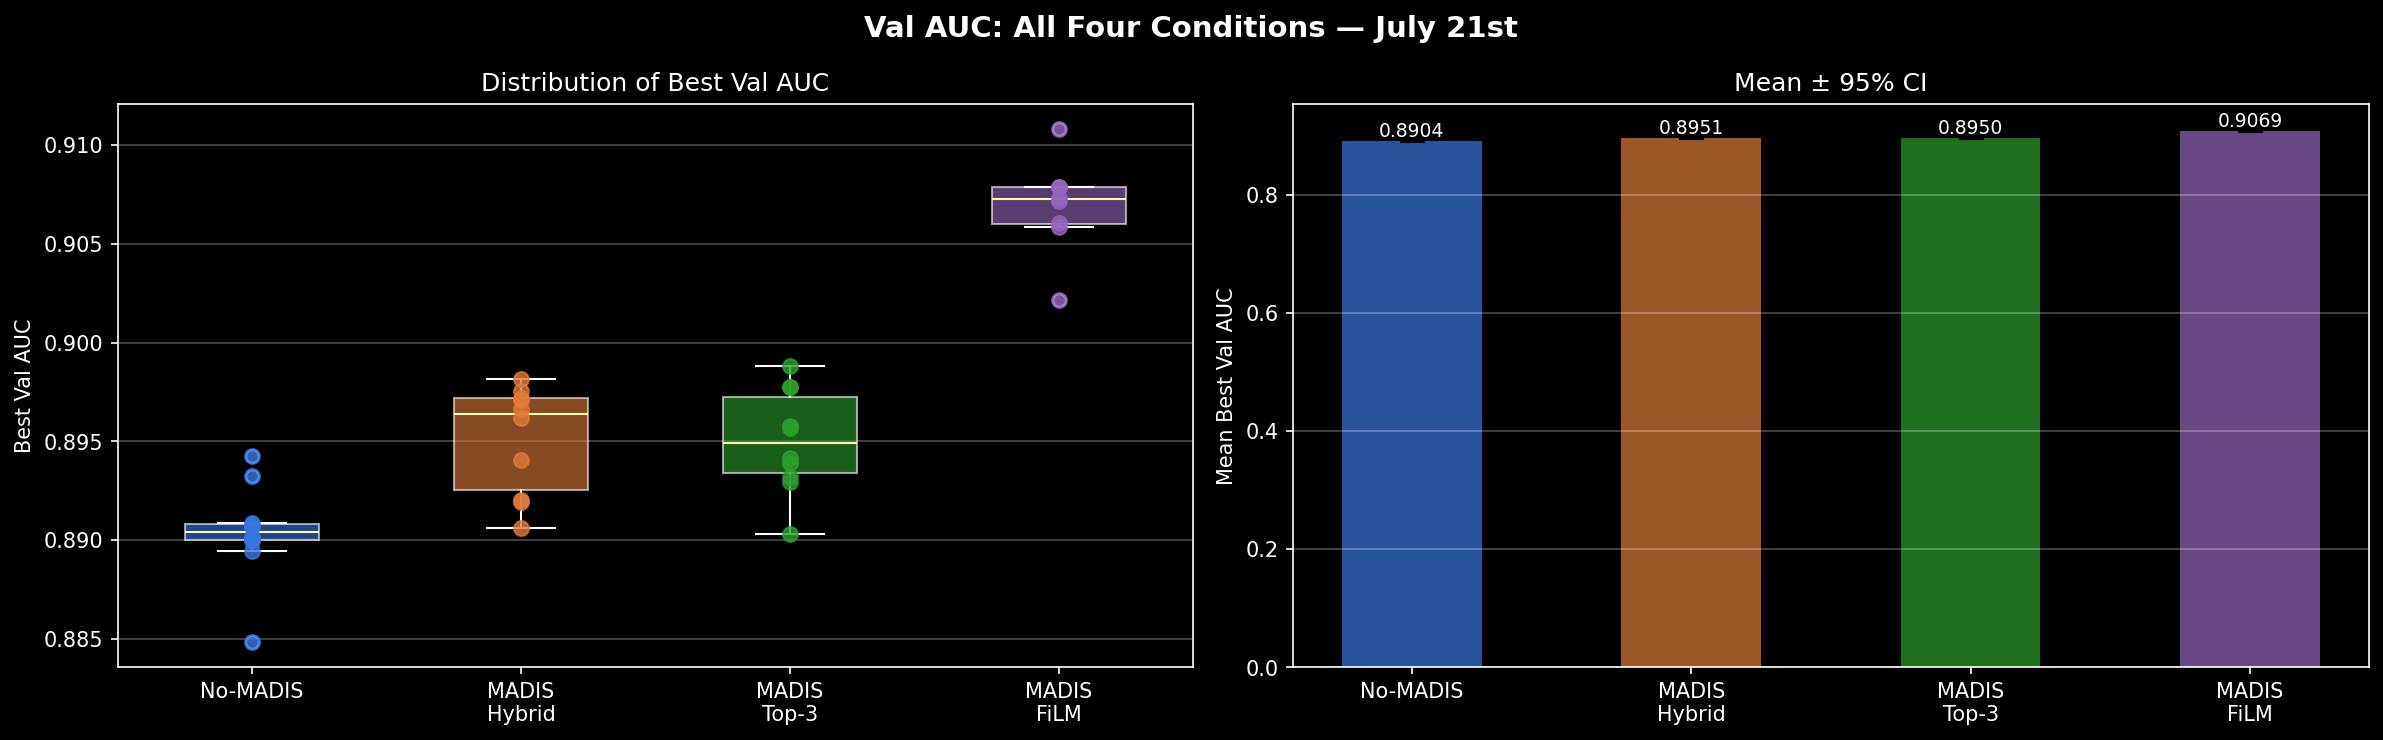

In [12]:
display(Image(filename=os.path.join(REPO_ROOT, "results", "july21_auc_distribution.png")))

## 4. Prediction API → Rails hand-off

The Flask API (`api/app.py`) should already be running in another terminal, serving all three trained checkpoints (`no_madis`, `madis`, `madis_film`) on `:5050`.

In [13]:
import requests

BASE_URL = "http://localhost:5050"

health = requests.get(f"{BASE_URL}/health").json()
health

{'status': 'ok'}

In [14]:
storms = requests.get(f"{BASE_URL}/storms/madis").json()
demo_storm_id = storms["storm_ids"][0]
print(f"Using storm_id={demo_storm_id} (one of {storms['count']} MADIS-eligible storms)")

Using storm_id=466395 (one of 12291 MADIS-eligible storms)


In [15]:
prediction = requests.get(f"{BASE_URL}/predict/{demo_storm_id}").json()
prediction

{'geojson': {'coordinates': [-92.99462494789428, 35.258759130676076],
  'type': 'Point'},
 'predictions': {'madis': {'available': True,
   'probability': 0.007340182084590197},
  'madis_film': {'available': True, 'probability': 0.00670624477788806},
  'no_madis': {'available': True, 'probability': 0.013528215698897839}},
 'radar_image_bounds': [[34.8775582376585, -93.47832882360333],
  [35.74089281766238, -92.5046681333758]],
 'radar_image_url': 'http://localhost:5050/static/radar/466395.png',
 'storm_id': 466395}

In [16]:
display(Image(url=prediction["radar_image_url"]))

**Now switch to the Rails app** to show this same storm_id rendered live on the map, consuming this same API response.